<a href="https://colab.research.google.com/github/ammarluqmann/jobsheet1_pengolahancitra/blob/main/JOBSHEET_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Praktikum 1: Menghitung Jarak Berbasis Piksel (Euclidean & Manhattan)

Jarak Euclidean Patch 1 & 2: 24.7650
Jarak Euclidean Patch 1 & 3: 5.0000
Jarak Manhattan Patch 1 & 2: 936.4392
Jarak Manhattan Patch 1 & 3: 250.0000


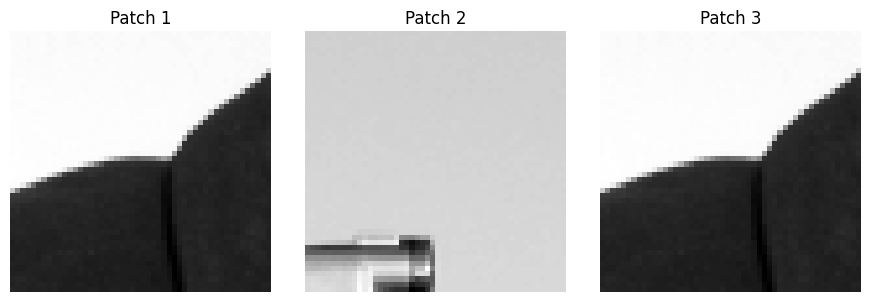

In [1]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

# 1. Ambil dua patch dari citra
image = img_as_float(data.camera())
patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350]
patch3 = patch1 + 0.1
patch3 = np.clip(patch3, 0, 1)

# 2. Ubah patch menjadi vektor 1D
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

# 3. Jarak Euclidean
dist_l2_12 = distance.euclidean(vec1, vec2)
dist_l2_13 = distance.euclidean(vec1, vec3)

# 4. Jarak Manhattan
dist_l1_12 = distance.cityblock(vec1, vec2)
dist_l1_13 = distance.cityblock(vec1, vec3)

# 5. Tampilkan hasil
print(f"Jarak Euclidean Patch 1 & 2: {dist_l2_12:.4f}")
print(f"Jarak Euclidean Patch 1 & 3: {dist_l2_13:.4f}")
print(f"Jarak Manhattan Patch 1 & 2: {dist_l1_12:.4f}")
print(f"Jarak Manhattan Patch 1 & 3: {dist_l1_13:.4f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(patch1, cmap='gray'); axes[0].set_title('Patch 1'); axes[0].axis('off')
axes[1].imshow(patch2, cmap='gray'); axes[1].set_title('Patch 2'); axes[1].axis('off')
axes[2].imshow(patch3, cmap='gray'); axes[2].set_title('Patch 3'); axes[2].axis('off')
plt.tight_layout()
plt.show()

Praktikum 2: Menghitung Cosine Similarity antara Histogram Warna

Cosine Similarity Astronaut vs Coffee: 0.8156
Cosine Similarity Astronaut vs Astronaut: 1.0000
Cosine Similarity Astronaut vs Downsampled: 1.0000


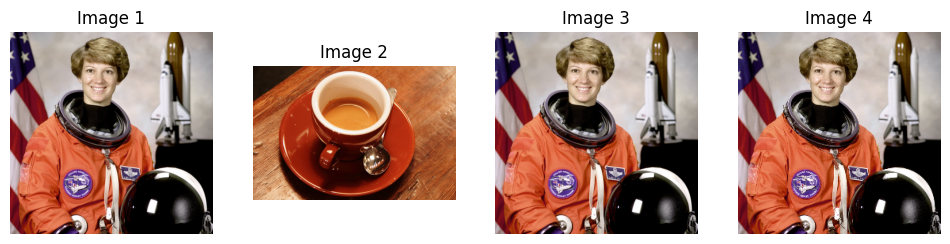

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte
from scipy.spatial import distance

def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)
    hist_r, _ = np.histogram(img_uint8[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(img_uint8[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(img_uint8[:,:,2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b)).astype(float)
    hist_combined /= np.sum(hist_combined)
    return hist_combined

image1 = data.astronaut()
image2 = data.coffee()
image3 = data.astronaut()
image4 = image1[::2, ::2, :]

hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)

sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)

print(f"Cosine Similarity Astronaut vs Coffee: {sim_12:.4f}")
print(f"Cosine Similarity Astronaut vs Astronaut: {sim_13:.4f}")
print(f"Cosine Similarity Astronaut vs Downsampled: {sim_14:.4f}")

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(image1); axes[0].set_title('Image 1'); axes[0].axis('off')
axes[1].imshow(image2); axes[1].set_title('Image 2'); axes[1].axis('off')
axes[2].imshow(image3); axes[2].set_title('Image 3'); axes[2].axis('off')
axes[3].imshow(image4); axes[3].set_title('Image 4'); axes[3].axis('off')
plt.show()

Praktikum 3: Menghitung Structural Similarity Index (SSIM)

SSIM Same: 1.0000
SSIM Noisy: 0.2953
SSIM Contrast: 0.9651
SSIM Blurred: 0.8027


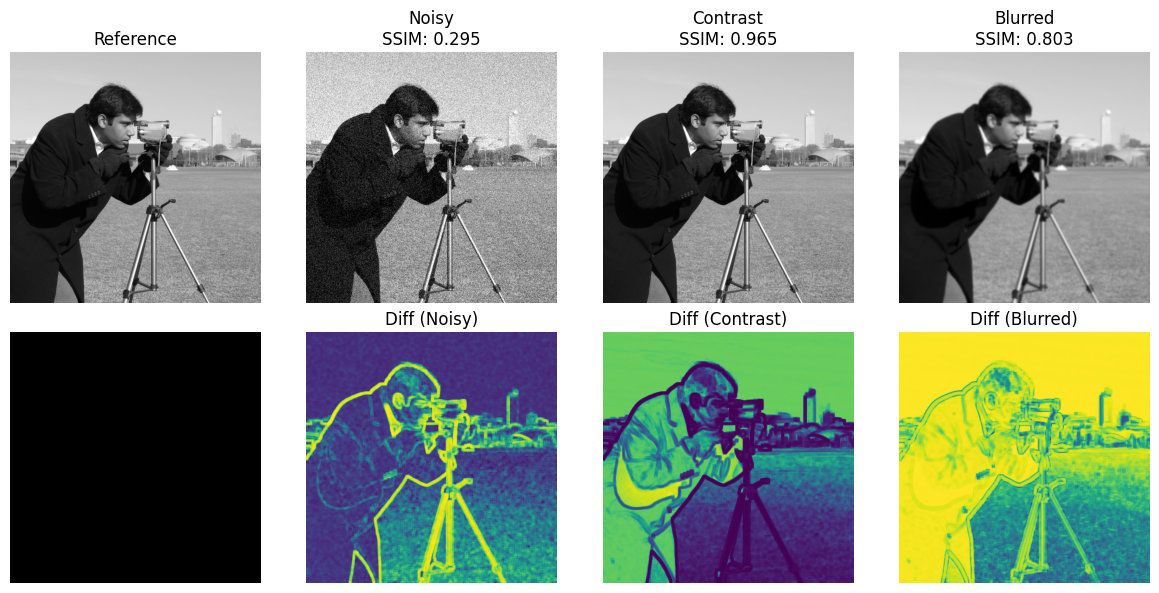

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.filters import gaussian
from skimage.util import random_noise

image_ref = img_as_float(data.camera())
image_same = image_ref.copy()
image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)
image_contrast = np.clip(image_ref * 0.8, 0, 1)
image_blurred = gaussian(image_ref, sigma=1.5)

data_range = image_ref.max() - image_ref.min()

ssim_same, _ = ssim(image_ref, image_same, data_range=data_range, full=True)
ssim_noisy, diff_noisy = ssim(image_ref, image_noisy, data_range=data_range, full=True)
ssim_contrast, diff_contrast = ssim(image_ref, image_contrast, data_range=data_range, full=True)
ssim_blurred, diff_blurred = ssim(image_ref, image_blurred, data_range=data_range, full=True)

print(f"SSIM Same: {ssim_same:.4f}")
print(f"SSIM Noisy: {ssim_noisy:.4f}")
print(f"SSIM Contrast: {ssim_contrast:.4f}")
print(f"SSIM Blurred: {ssim_blurred:.4f}")

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()
axes[0].imshow(image_ref, cmap='gray'); axes[0].set_title('Reference'); axes[0].axis('off')
axes[1].imshow(image_noisy, cmap='gray'); axes[1].set_title(f'Noisy\nSSIM: {ssim_noisy:.3f}'); axes[1].axis('off')
axes[2].imshow(image_contrast, cmap='gray'); axes[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}'); axes[2].axis('off')
axes[3].imshow(image_blurred, cmap='gray'); axes[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}'); axes[3].axis('off')
axes[4].imshow(np.zeros_like(image_ref), cmap='gray'); axes[4].axis('off')
axes[5].imshow(diff_noisy, cmap='viridis'); axes[5].set_title('Diff (Noisy)'); axes[5].axis('off')
axes[6].imshow(diff_contrast, cmap='viridis'); axes[6].set_title('Diff (Contrast)'); axes[6].axis('off')
axes[7].imshow(diff_blurred, cmap='viridis'); axes[7].set_title('Diff (Blurred)'); axes[7].axis('off')
plt.tight_layout()
plt.show()

Praktikum 4: Template Matching

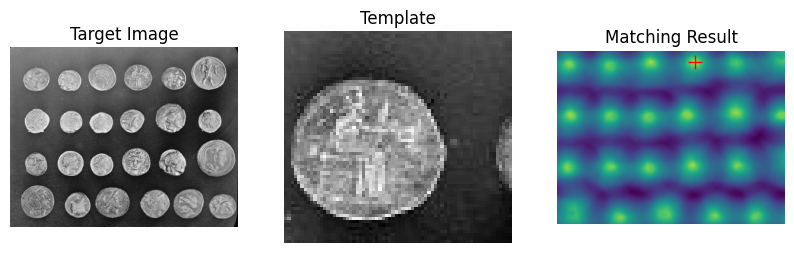

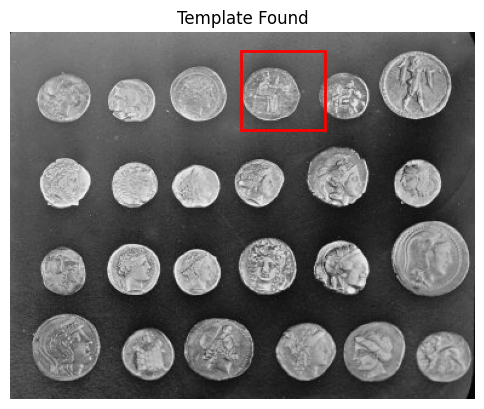

Template ditemukan di koordinat (x,y): (190, 15)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

image = data.coins()
template = image[15:80, 190:260]
result = match_template(image, template)
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]

fig, ax = plt.subplots(1, 3, figsize=(10, 4))
ax[0].imshow(image, cmap='gray'); ax[0].set_title('Target Image'); ax[0].axis('off')
ax[1].imshow(template, cmap='gray'); ax[1].set_title('Template'); ax[1].axis('off')
ax[2].imshow(result, cmap='viridis'); ax[2].set_title('Matching Result'); ax[2].plot(x, y, 'r+', markersize=10); ax[2].axis('off')

fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray'); ax_main.set_title('Template Found'); ax_main.axis('off')
h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main.add_patch(rect)
plt.show()

print(f"Template ditemukan di koordinat (x,y): ({x}, {y})")

Praktikum 5: Simulasi CBIR Sederhana

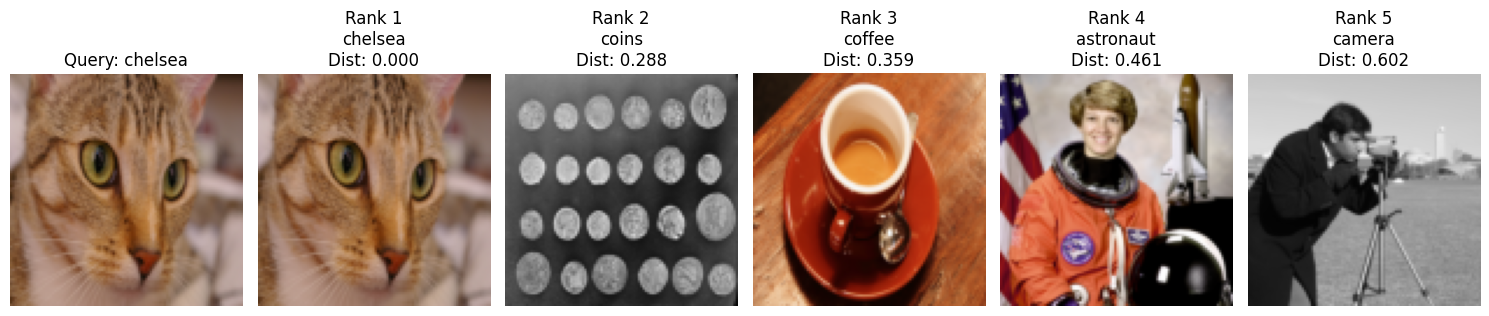

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_float
from scipy.spatial import distance

def calculate_rgb_histogram(image, bins=16):
    from skimage import img_as_ubyte
    if image.dtype == float:
        image = img_as_ubyte(image)
    hist_r, _ = np.histogram(image[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:,:,2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b)).astype(float)
    hist_combined /= hist_combined.sum() if hist_combined.sum() != 0 else 1
    return hist_combined

image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []

for name in image_db_names:
    img = getattr(data, name)()
    if img.ndim == 2:
        img = color.gray2rgb(img)
    img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
    database_images.append(img_resized)
    database_hists.append(calculate_rgb_histogram(img_resized))

query_index = image_db_names.index("chelsea")
query_image = database_images[query_index]
query_hist = database_hists[query_index]

distances = [distance.cosine(query_hist, hist) for hist in database_hists]
sorted_indices = np.argsort(distances)

fig, axes = plt.subplots(1, len(database_images) + 1, figsize=(15, 3))
axes[0].imshow(query_image); axes[0].set_title("Query: chelsea"); axes[0].axis('off')

for i, idx in enumerate(sorted_indices):
    ax = axes[i+1]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {i+1}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')

plt.tight_layout()
plt.show()

Tugas No 3

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin ke kanan, semakin tidak mirip):
Rank 1: chelsea (Distance:0.000)
Rank 2: astronaut (Distance:0.050)
Rank 3: coffee (Distance:0.176)
Rank 4: camera (Distance:0.194)
Rank 5: coins (Distance:0.211)


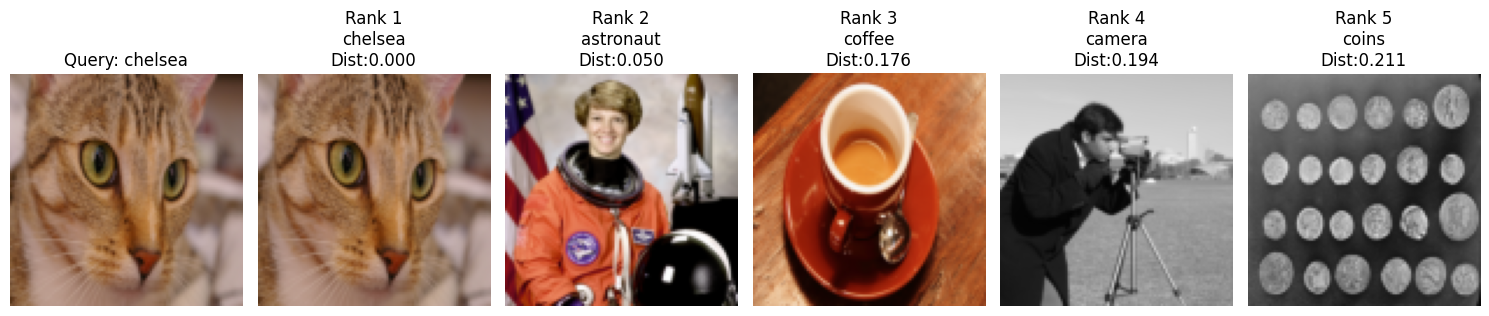

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform

# Fungsi hitung rata-rata warna
def calculate_rgb_mean(image):
    return np.mean(image.reshape(-1, 3), axis=0)  # Hitung rata-rata RGB

# 1. Siapkan database citra dan fitur mean warna
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_means = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        if img.ndim == 2:  # Konversi grayscale ke RGB jika perlu
            img = color.gray2rgb(img)
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_means.append(calculate_rgb_mean(img_resized))
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

# Pilih satu citra sebagai query (misal, 'chelsea' si kucing)
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_mean = database_means[query_index]

# 2. Hitung jarak Euclidean antara query dan semua citra di database
distances = [np.linalg.norm(query_mean - mean) for mean in database_means]

# 3. Urutkan hasil retrieval berdasarkan jarak
sorted_indices = np.argsort(distances)

# 4. Tampilkan hasil retrieval
num_results_to_show = len(database_images)
fig, axes = plt.subplots(1, num_results_to_show + 1, figsize=(15, 3))

# Tampilkan query
axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_image_name}")
axes[0].axis('off')

# Tampilkan hasil terurut
print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip):")
for i, idx in enumerate(sorted_indices):
    img_rank = i + 1
    ax = axes[img_rank]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {img_rank}\n{image_db_names[idx]}\nDist:{distances[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {img_rank}: {image_db_names[idx]} (Distance:{distances[idx]:.3f})")

plt.tight_layout()
plt.show()

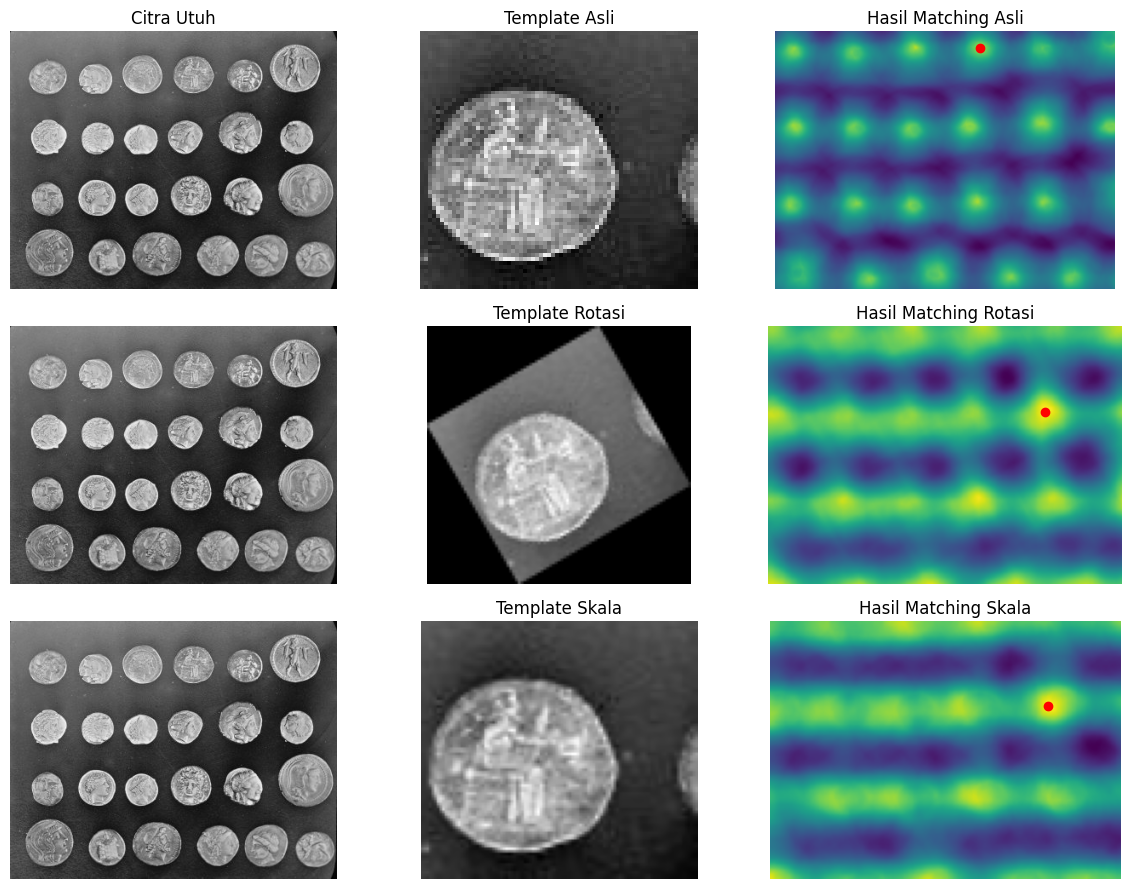

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template
from skimage.transform import rotate, rescale

image = data.coins()
template = image[15:80, 190:260]

template_rotated = rotate(template, angle=30, resize=True)
template_scaled = rescale(template, scale=1.5, anti_aliasing=True, channel_axis=None)

result_original = match_template(image, template)
ij_original = np.unravel_index(np.argmax(result_original), result_original.shape)
x0, y0 = ij_original[::-1]

result_rotated = match_template(image, template_rotated)
ij_rotated = np.unravel_index(np.argmax(result_rotated), result_rotated.shape)
x1, y1 = ij_rotated[::-1]

result_scaled = match_template(image, template_scaled)
ij_scaled = np.unravel_index(np.argmax(result_scaled), result_scaled.shape)
x2, y2 = ij_scaled[::-1]

fig, axs = plt.subplots(3, 3, figsize=(12, 9))

axs[0, 0].imshow(image, cmap='gray')
axs[0, 0].set_title("Citra Utuh"); axs[0, 0].axis('off')
axs[0, 1].imshow(template, cmap='gray')
axs[0, 1].set_title("Template Asli"); axs[0, 1].axis('off')
axs[0, 2].imshow(result_original, cmap='viridis')
axs[0, 2].set_title("Hasil Matching Asli"); axs[0, 2].plot(x0, y0, 'ro'); axs[0, 2].axis('off')

axs[1, 0].imshow(image, cmap='gray'); axs[1, 0].axis('off')
axs[1, 1].imshow(template_rotated, cmap='gray')
axs[1, 1].set_title("Template Rotasi"); axs[1, 1].axis('off')
axs[1, 2].imshow(result_rotated, cmap='viridis')
axs[1, 2].set_title("Hasil Matching Rotasi"); axs[1, 2].plot(x1, y1, 'ro'); axs[1, 2].axis('off')

axs[2, 0].imshow(image, cmap='gray'); axs[2, 0].axis('off')
axs[2, 1].imshow(template_scaled, cmap='gray')
axs[2, 1].set_title("Template Skala"); axs[2, 1].axis('off')
axs[2, 2].imshow(result_scaled, cmap='viridis')
axs[2, 2].set_title("Hasil Matching Skala"); axs[2, 2].plot(x2, y2, 'ro'); axs[2, 2].axis('off')

plt.tight_layout()
plt.show()